In [10]:
source("Main.R")
source("Utilities.R")
source("Conf.R")

In [11]:
SampleSheet=read.csv("./TextFiles/SampleSheet.csv")
rownames(SampleSheet)=SampleSheet$SampleName

In [14]:
compute_square_matrices <- function(df) {
  
  # Keep only significant rows
  df_sig <- df[df$pertSign == TRUE, c("condition", "perturbation")]
  
  # Unique conditions
  conditions <- sort(unique(df_sig$condition))
  n <- length(conditions)
  
  # Prepare empty matrices
  mat_nboth <- matrix(0, nrow = n, ncol = n,
                      dimnames = list(conditions, conditions))
  mat_jaccard <- matrix(0, nrow = n, ncol = n,
                        dimnames = list(conditions, conditions))
  
  # Build list mapping condition → significant perturbations
  cond_to_perts <- list()
  for (cond in conditions) {
    cond_to_perts[[cond]] <- unique(df_sig$perturbation[df_sig$condition == cond])
  }
  
  # Fill matrices
  for (i in seq_len(n)) {
    for (j in seq_len(n)) {
      set1 <- cond_to_perts[[conditions[i]]]
      set2 <- cond_to_perts[[conditions[j]]]
      
      inter_size <- length(intersect(set1, set2))
      union_size <- length(union(set1, set2))
      
      mat_nboth[i, j] <- inter_size
      mat_jaccard[i, j] <- if (union_size == 0) 0 else inter_size / union_size
    }
  }
  
  return(list(n_both = mat_nboth, jaccard = mat_jaccard))
}

# ----- Usage -----
result <- compute_square_matrices(allRes_cosine)
n_both_matrix <- result$n_both
jaccard_matrix <- result$jaccard


In [15]:
n_both_matrix

,AR-A014418,AZD4573,CHIR,CHIR-98014,DMSO,DMSO_round2,KYA,LDN,Lexibulin,PFI1,PP121,RGFP,Romidepsin,Stattic
AR-A014418,1230,1054,1065,1023,1122,1103,1127,1131,1025,1056,997,1126,1110,1035
AZD4573,1054,1082,972,970,1036,1044,1043,1031,1017,980,987,1041,1059,1022
CHIR,1065,972,1379,1039,1277,1051,1260,1300,926,1263,917,1265,1037,941
CHIR-98014,1023,970,1039,1112,1022,1009,1024,1032,953,978,933,1021,998,957
DMSO,1122,1036,1277,1022,1431,1112,1341,1390,995,1326,969,1361,1100,1008
DMSO_round2,1103,1044,1051,1009,1112,1179,1111,1120,1001,1063,979,1115,1102,1012
KYA,1127,1043,1260,1024,1341,1111,1415,1346,1012,1270,992,1360,1107,1021
LDN,1131,1031,1300,1032,1390,1120,1346,1479,993,1342,970,1370,1105,1004
Lexibulin,1025,1017,926,953,995,1001,1012,993,1068,933,984,1007,1028,1027
PFI1,1056,980,1263,978,1326,1063,1270,1342,933,1396,922,1290,1049,948


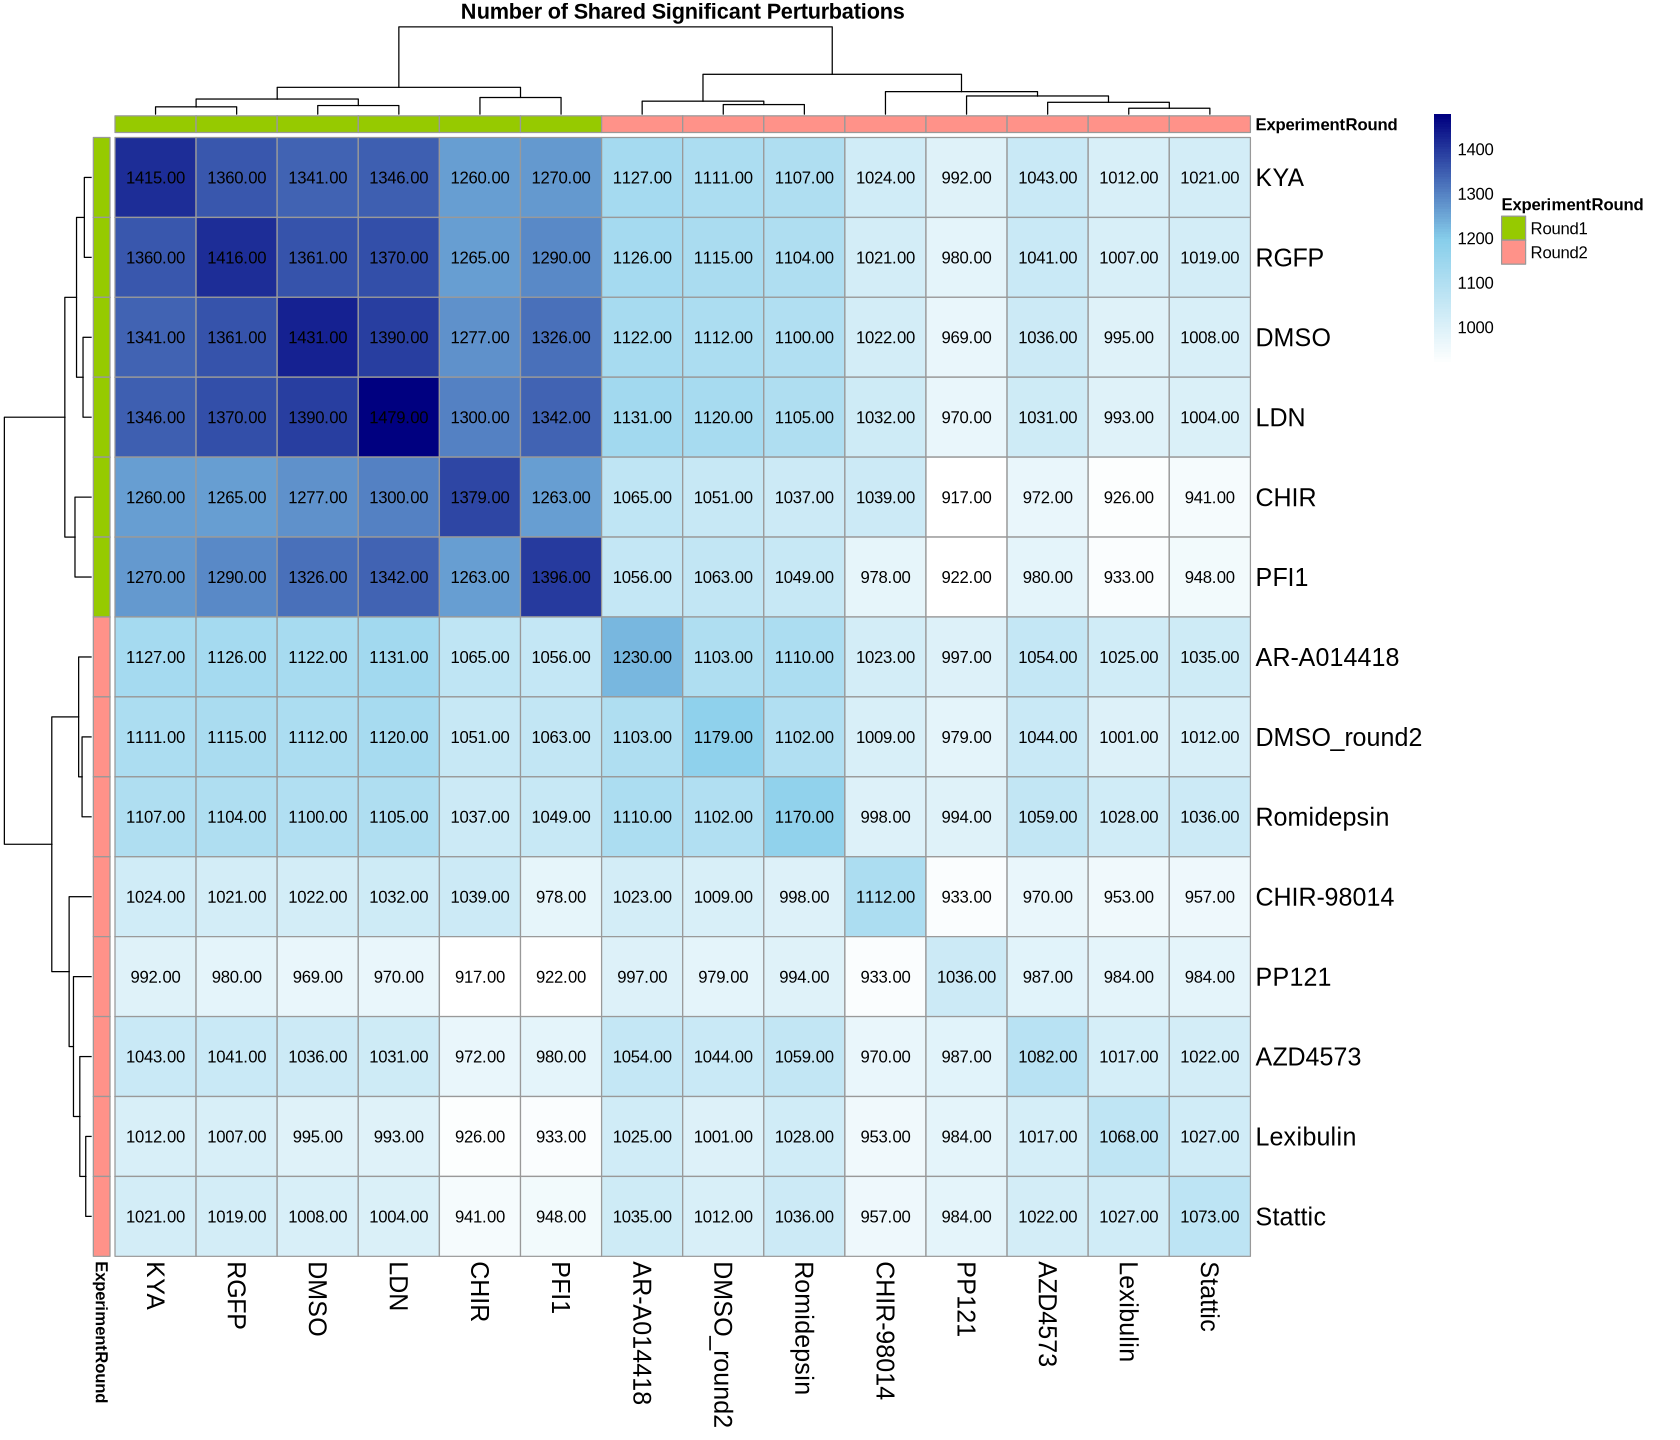

In [16]:
options(repr.plot.width = 14, repr.plot.height = 12)
SampleSheet=read.csv("./TextFiles/SampleSheet.csv")
SampleSheet[SampleSheet$SampleName=="PFI-1","SampleName"]="PFI1"
rownames(SampleSheet)=SampleSheet$SampleName

SampleSheet <- SampleSheet[rownames(n_both_matrix),]
annots=copy(SampleSheet)
annots$SampleName=NULL

pheatmap(
  n_both_matrix,
  display_numbers = TRUE,
  number_color = "black",
  fontsize_number = 10,
  fontsize_col=15,fontsize_row=15,
  annotation_col=annots, annotation_row=annots,
  color = colorRampPalette(c("white", "skyblue", "navy"))(100),
  main = "Number of Shared Significant Perturbations"
)

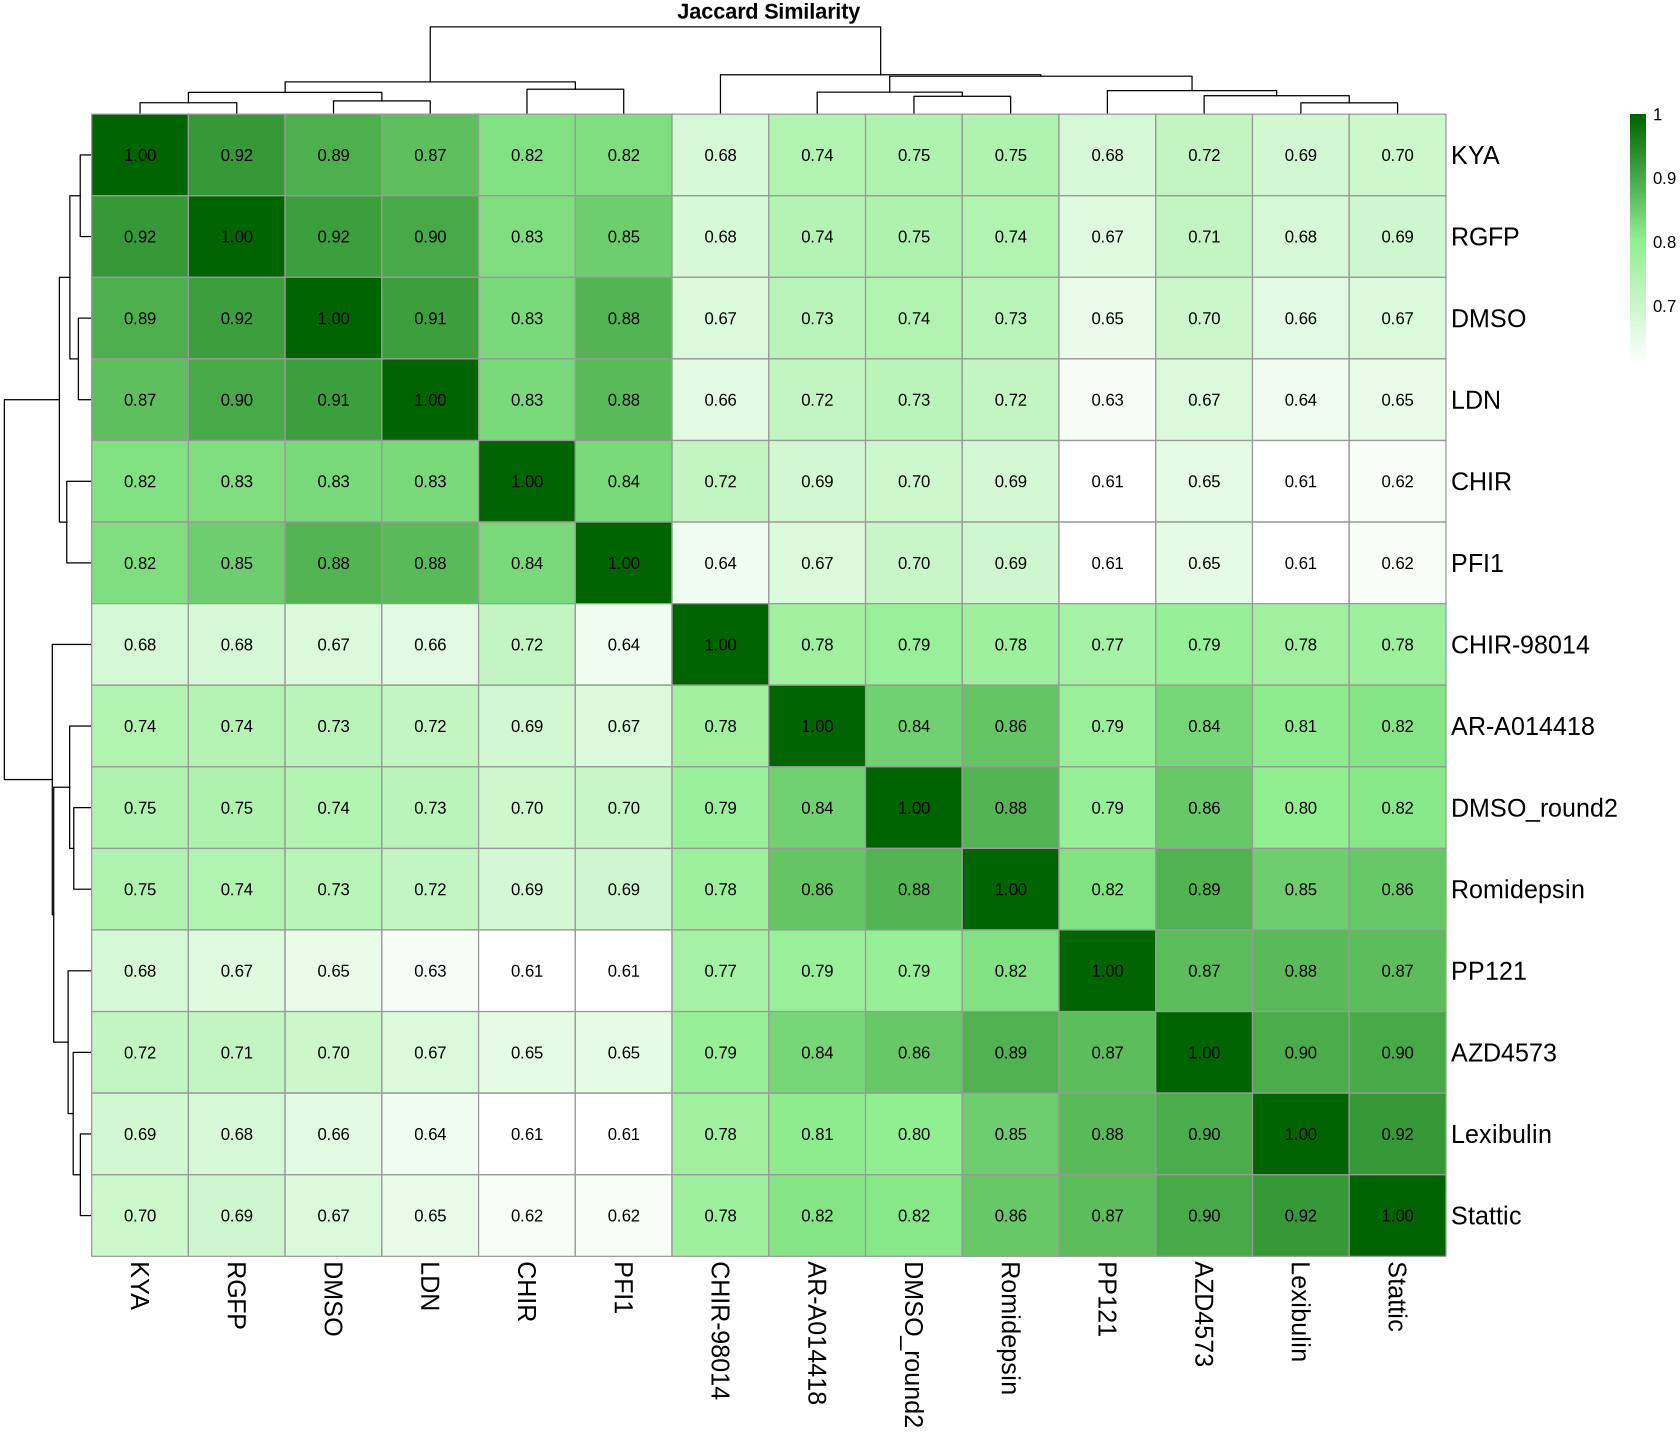

In [17]:
pheatmap(
  jaccard_matrix,
  display_numbers = TRUE,
  number_color = "black",
  fontsize_number = 10,
  fontsize_col=15,fontsize_row=15,
  color = colorRampPalette(c("white", "lightgreen", "darkgreen"))(100),
  main = "Jaccard Similarity"
)

Warning message:
“Removed 5442 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 56 rows containing missing values or values outside the scale range (`geom_bar()`).”


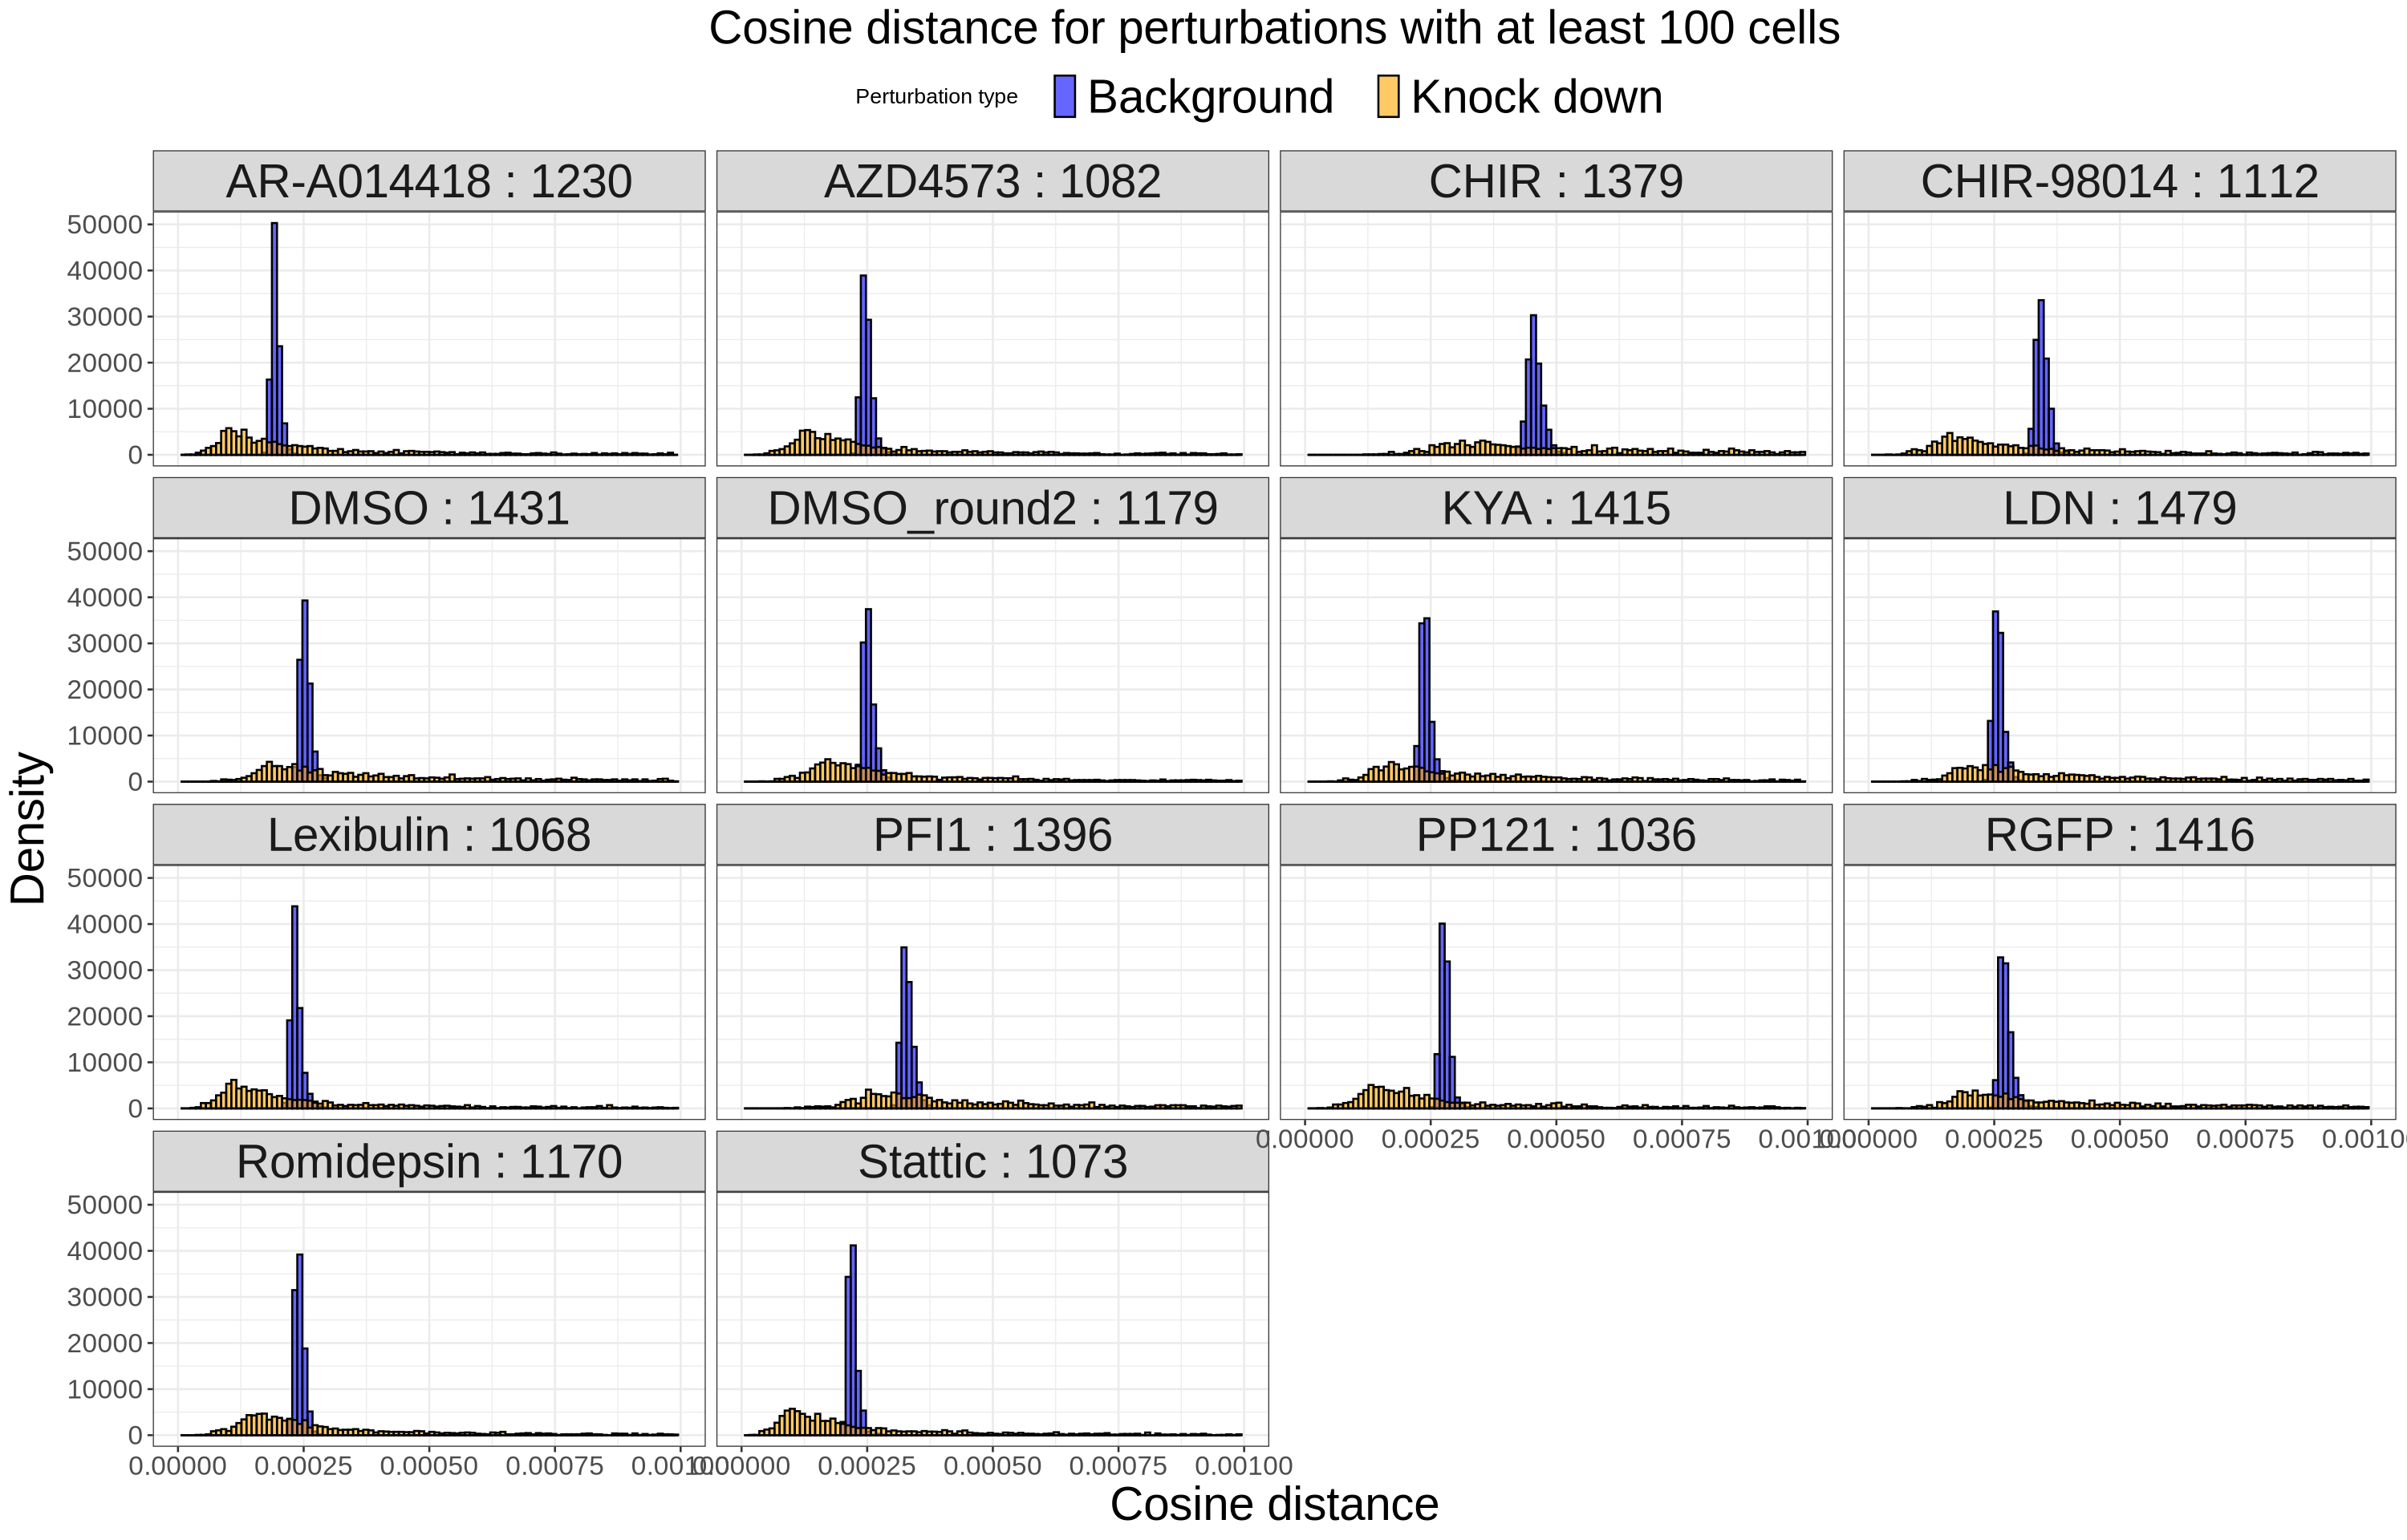

In [18]:
options(repr.plot.width = 25, repr.plot.height = 16)
allRes_cosine_min100 <- allRes_cosine[allRes_cosine$n_pert > 100,]
allRes_cosine_min100$conditionTitle = paste0(allRes_cosine_min100$condition, " : ", 
                                      allRes_cosine_min100$nSign_200)

ggplot(allRes_cosine_min100, aes(x = cosine_distance_means, fill = pertType)) +
      geom_histogram(aes(y = after_stat(density)),alpha = 0.6,
                     position = "identity", bins = 100, color = "black") +
      facet_wrap(~conditionTitle)+
      theme_bw(base_size = 16) +
      labs(
        title=paste0("Cosine distance for perturbations with at least 100 cells"),
        x = "Cosine distance",
        y = "Density",
        fill = "Perturbation type"
      ) +
      theme(
        legend.position = "top",
          legend.text=element_text(size=35),
          axis.text = element_text(size=20),
          axis.title = element_text(size=35),
        plot.title = element_text(hjust = 0.5,size=35),
        strip.text=element_text(size=35)
      )+scale_fill_manual(
        values = c("blue", "orange")
      )+xlim(0,0.001)

In [19]:
result <- compute_square_matrices(allRes_cosine_min100)
n_both_matrix <- result$n_both
jaccard_matrix <- result$jaccard


In [22]:
length(unique(allRes_cosine_min100$perturbation))

[1] 1925

In [23]:
dmso_sign=allRes_cosine_min100[(allRes_cosine_min100[,"condition"] %in% c("DMSO","DMSO_round2")),]
dmso_sign = dmso_sign[dmso_sign$pertSign == TRUE,]
write.csv(dmso_sign,"dmso_sign.csv")
chir_sign=allRes_cosine_min100[(allRes_cosine_min100[,"condition"] %in% c("CHIR","CHIR-98014")),]
chir_sign = chir_sign[chir_sign$pertSign == TRUE,]
write.csv(chir_sign,"CHIR_sign.csv")

In [24]:
chir_sign_arshia=allRes_cosine_min100[(allRes_cosine_min100[,"condition"] %in% c("CHIR")),]
chir_sign_arshia = chir_sign_arshia[chir_sign_arshia$pertSign == TRUE,]
write.csv(chir_sign_arshia,"CHIR_sign_arshia.csv")

In [25]:
dim(chir_sign_arshia)

[1] 1147   14

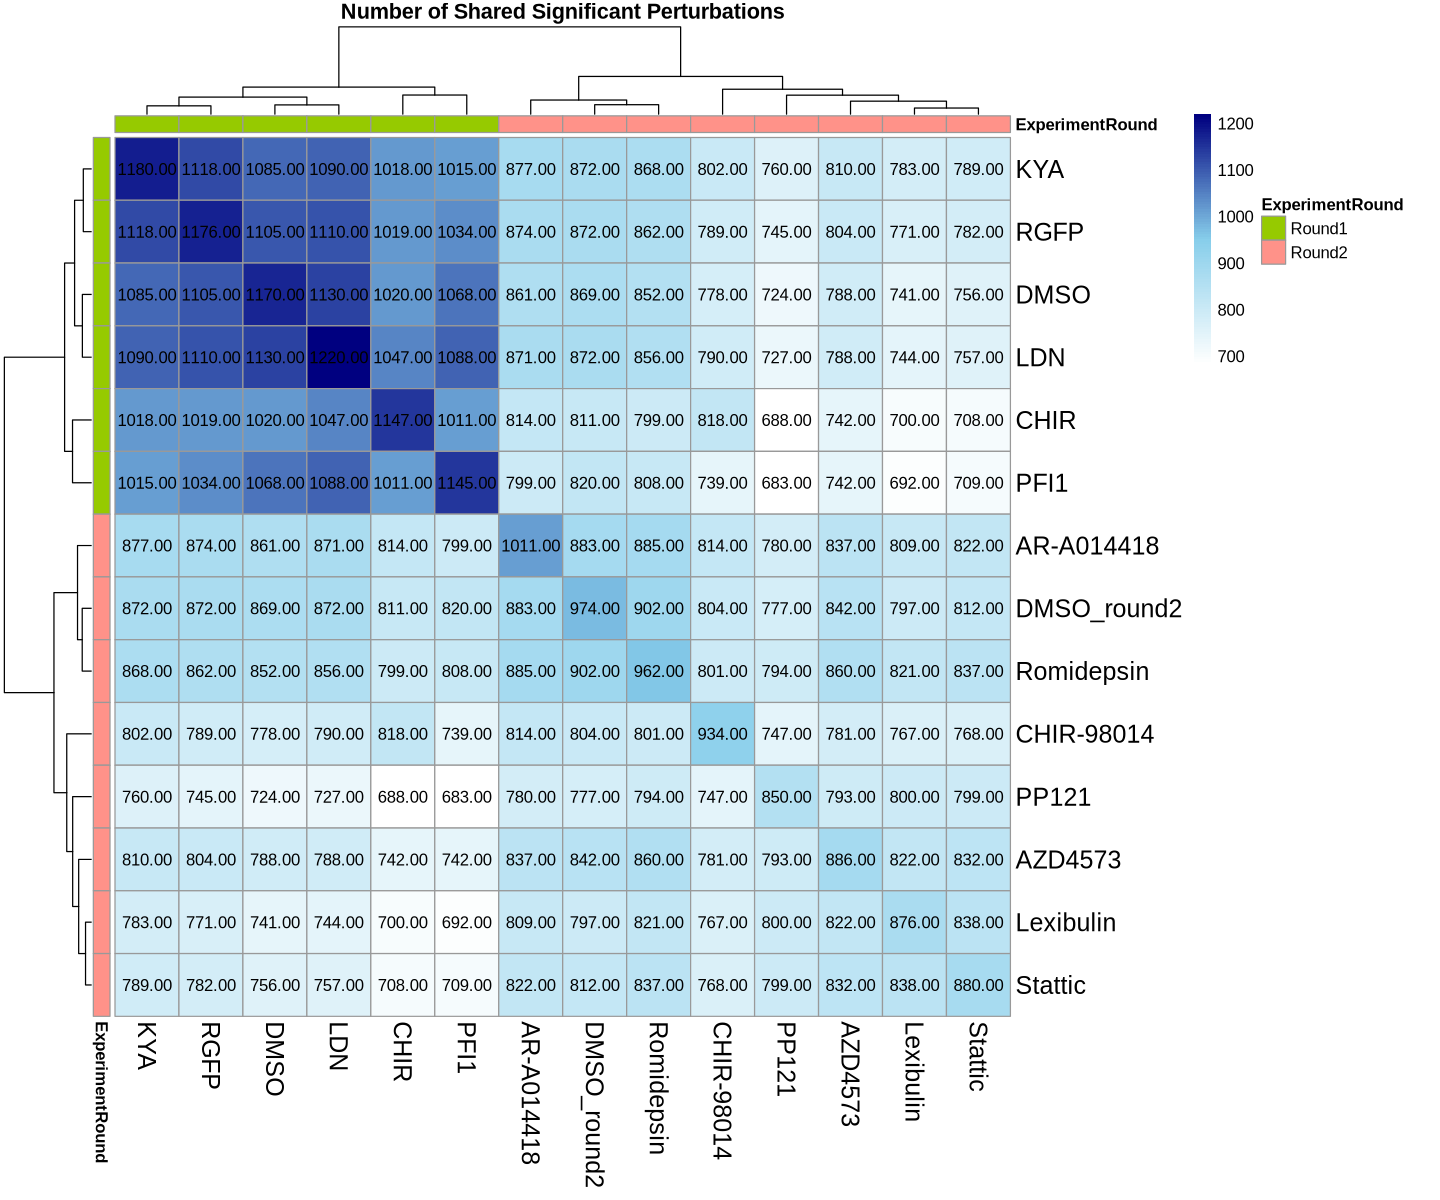

In [26]:
options(repr.plot.width = 12, repr.plot.height = 10)
SampleSheet=read.csv("./TextFiles/SampleSheet.csv")
SampleSheet[SampleSheet$SampleName=="PFI-1","SampleName"]="PFI1"
rownames(SampleSheet)=SampleSheet$SampleName

SampleSheet <- SampleSheet[rownames(n_both_matrix),]
annots=copy(SampleSheet)
annots$SampleName=NULL

pheatmap(
  n_both_matrix,
  display_numbers = TRUE,
  number_color = "black",
  fontsize_number = 10,
  fontsize_col=15,fontsize_row=15,
  annotation_col=annots, annotation_row=annots,
  color = colorRampPalette(c("white", "skyblue", "navy"))(100),
  main = "Number of Shared Significant Perturbations"
)

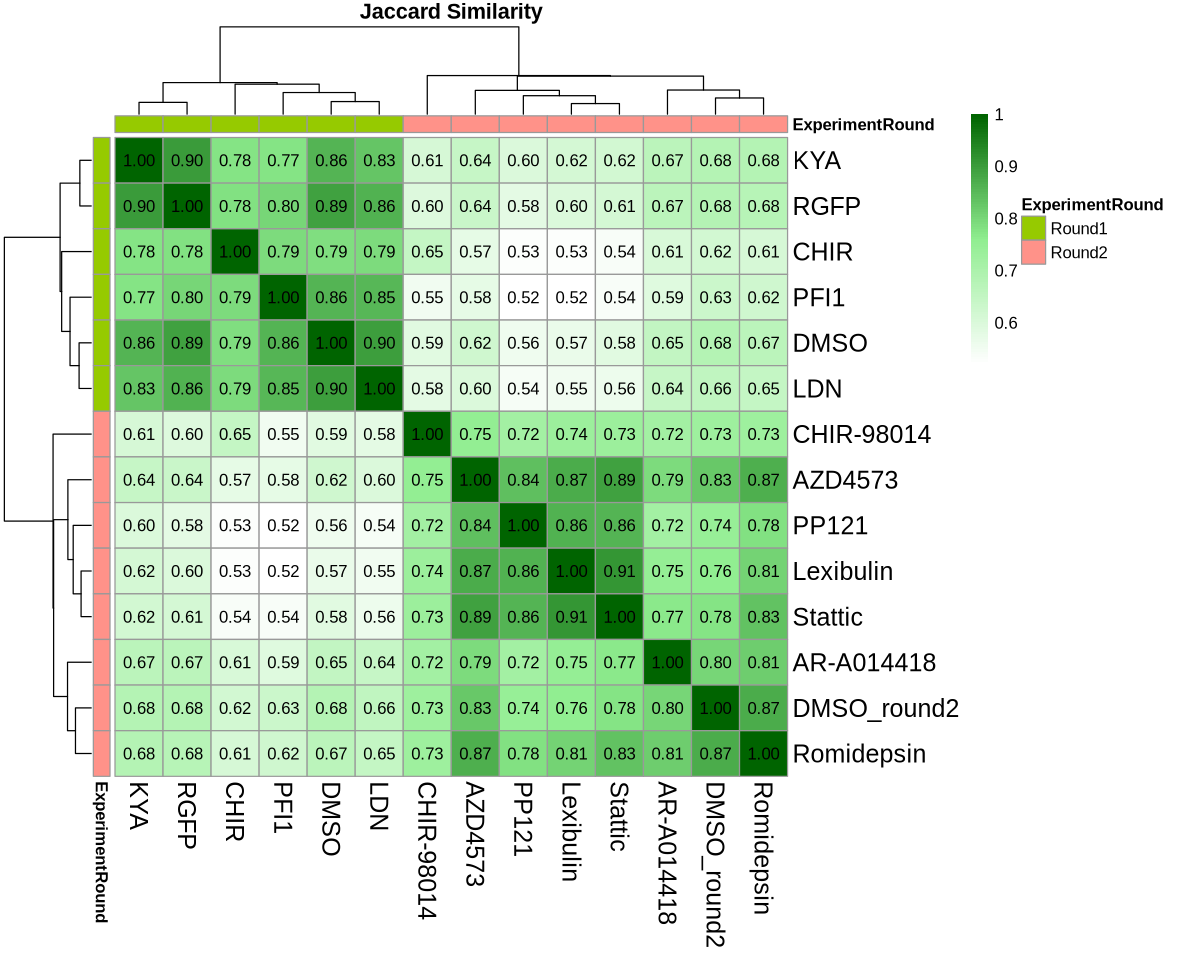

In [27]:
options(repr.plot.width = 10, repr.plot.height = 8)

pheatmap(
  jaccard_matrix,
  display_numbers = TRUE,
  number_color = "black",
  fontsize_number = 10,
  fontsize_col=15,fontsize_row=15,
   annotation_col=annots, annotation_row=annots,
  color = colorRampPalette(c("white", "lightgreen", "darkgreen"))(100),
  main = "Jaccard Similarity"
)

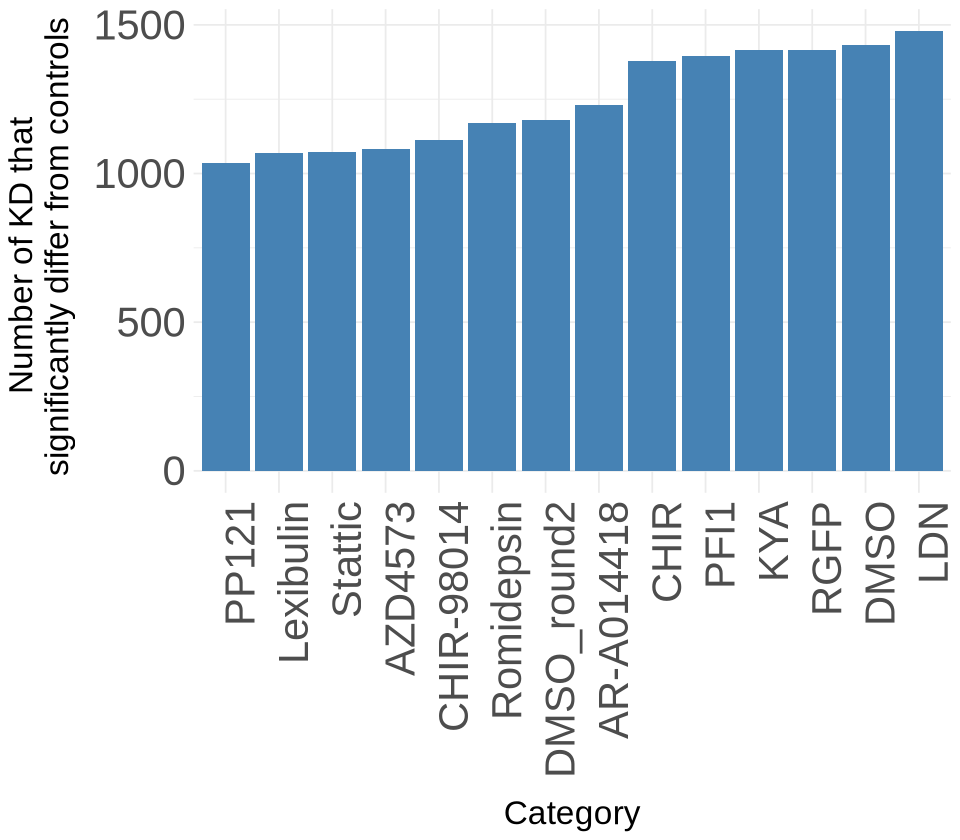

In [30]:
options(repr.plot.width = 8, repr.plot.height = 7)

s=unique(allRes_cosine_min100[,c("condition", "nSign_200")])
s=s[order(s$nSign_200),]
s$condition=factor(s$condition, levels=s$condition)

ggplot(s, aes(x = condition, y = nSign_200)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs( x = "Category", y = "Value") +
  theme_minimal()+theme(
        axis.text=element_text(size=25),
        axis.title=element_text(size=20),
        axis.text.x=element_text(hjust=1, angle=90)
      )+ylab("Number of KD that \n significantly differ from controls")

In [31]:
allRes_cosine_min100_sgn = allRes_cosine_min100[allRes_cosine_min100$pertSign == TRUE,]

In [33]:
selPerts = unique(allRes_cosine_min100_sgn$perturbation)
length(selPerts)

[1] 1525

In [35]:
write.csv(allRes_cosine_min100_sgn,"SignificantPerturbations.csv")

In [ ]:
allRes_cosine_min100_sgn_wide <- reshape(
  allRes_cosine_min100_sgn[, c("perturbation", "condition", "n_ctrl")],
  idvar   = "perturbation",
  timevar = "condition",
  direction = "wide"
)

rownames(allRes_cosine_min100_sgn_wide) = allRes_cosine_min100_sgn_wide$perturbation
allRes_cosine_min100_sgn_wide$perturbation = NULL

allRes_cosine_min100_sgn_wide[is.na(allRes_cosine_min100_sgn_wide)] = 0
allRes_cosine_min100_sgn_wide[allRes_cosine_min100_sgn_wide > 0] = 1
colnames(allRes_cosine_min100_sgn_wide) =sapply(colnames(allRes_cosine_min100_sgn_wide), function(x){strsplit(x,"n_ctrl.")[[1]][2]})


In [ ]:
options(repr.plot.width = 10, repr.plot.height = 9)

SampleSheet=read.csv("./TextFiles/SampleSheet.csv")
SampleSheet[SampleSheet$SampleName=="PFI-1","SampleName"]="PFI1"
rownames(SampleSheet)=SampleSheet$SampleName

SampleSheet <- SampleSheet[colnames(allRes_cosine_min100_sgn_wide),]
annots=copy(SampleSheet)
annots$SampleName=NULL


pheatmap(
  allRes_cosine_min100_sgn_wide,
  number_color = "black",
  fontsize_number = 10,
  fontsize_col=25,fontsize_row=1,
  annotation_col=annots,
  color = colorRampPalette(c("white", "navy"))(100),
  main = "Significant KD"
)

In [ ]:
library(dplyr)
library(ggplot2)

# df has columns: perturbation, condition
pert_counts <- allRes_cosine_min100_sgn %>%
  distinct(perturbation, condition) %>%       # avoid duplicates
  count(perturbation, name = "n_conditions")  # count conditions per perturbation

max_k <- max(pert_counts$n_conditions)

cumulative_df <- data.frame(
  k = 1:max_k,
  n_perts = sapply(1:max_k, function(k) sum(pert_counts$n_conditions >= k))
)

ggplot(cumulative_df, aes(x = k, y = n_perts)) +
  geom_line(size = 1.2, color = "blue") +
  geom_point(size = 2) +
  theme_bw(base_size = 16) +
  scale_x_continuous(breaks = cumulative_df$k) +   # ← show all x values
  labs(
    title = "Cumulative Distribution of \n Perturbation Occurrence Across Conditions",
    x = "Number of drug conditions (k)",
    y = "Number of KDs significant in ≥ k drug conditions"
  )+theme_minimal()+theme(
        axis.text=element_text(size=25),
        axis.title=element_text(size=20),
        plot.title = element_text(size = 20) 
      )


In [ ]:
#write.csv(allRes_cosine,"ContextSignificance.csv")

In [ ]:
# allRes_ModelTrain = copy(allRes_cosine)
# allRes_ModelTrain=allRes_ModelTrain[allRes_ModelTrain$n_pert > 199,]

# #allRes_ModelTrain = allRes_ModelTrain[allRes_ModelTrain$pertSign == TRUE,]
# k=table(allRes_ModelTrain$perturbation)
# pertWithCells = names(k>10)
# allRes_ModelTrain = allRes_ModelTrain[allRes_ModelTrain$perturbation %in% pertWithCells,]
# allRes_ModelTrain_sgn = allRes_ModelTrain[allRes_ModelTrain$pertSign == TRUE,]
# mySelPerts=unique(allRes_ModelTrain_sgn$perturbation)

# perClust=read.csv("PerturbationClusters_v3.csv", row.names = 1)
# perClust$perturbation = rownames(perClust)
# perClustLeiden=perClust[,c("perturbation","leiden")]

# perClust$perturbation=NULL
# perClust$leiden=NULL
# perClust[perClust == -10] = NA
# perClustLeiden$contextSpecIndex = rowMeans(perClust, na.rm = TRUE)
# perClustLeiden = perClustLeiden[perClustLeiden$perturbation %in% mySelPerts,]
# #write.csv(perClustLeiden,"SelectedPerturbations.csv")
# dim(perClustLeiden)

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 8)
allRes_cosine = allRes_cosine[allRes_cosine$pertType == "Knock down",]
allRes_cosine_min100 = allRes_cosine[allRes_cosine$perturbation %in% selPerts,]

allRes_sgn <- allRes_cosine_min100[!is.na(allRes_cosine_min100$cosine_distance_means),]

allRes_sgn_wide=reshape(allRes_sgn[,c("perturbation", "condition", "cosine_distance_means")],
        idvar = "perturbation", timevar = "condition", direction = "wide")

allRes_sgn_wide$cosine_distance_means.NA = NULL

#colnames(allRes_sgn_wide) = c("perturbation", "CHIR","DMSO","KYA","LDN","PFI1","RGFP")

rownames(allRes_sgn_wide) = allRes_sgn_wide$perturbation
allRes_sgn_wide$perturbation = NULL
allRes_sgn_wide[is.na(allRes_sgn_wide)]=0

#allRes_sgn_wide = allRes_sgn_wide*1000
allRes_sgn_wide[allRes_sgn_wide>0.002]=0.002
colnames(allRes_sgn_wide)=sapply(colnames(allRes_sgn_wide),function(x){strsplit(x,"cosine_distance_means.")[[1]][2]})

SampleSheet=read.csv("./TextFiles/SampleSheet.csv")
SampleSheet[SampleSheet$SampleName=="PFI-1","SampleName"]="PFI1"
rownames(SampleSheet)=SampleSheet$SampleName

SampleSheet <- SampleSheet[colnames(allRes_cosine_min100_sgn_wide),]
annots=copy(SampleSheet)
annots$SampleName=NULL


k=pheatmap(t(allRes_sgn_wide), na_col = "grey", 
    annotation_row=annots,
  clustering_method = "ward.D2",fontsize_col=1,fontsize_row=25)
pertNames=colnames(t(allRes_sgn_wide))[k$tree_col$order]
condNames=rownames(t(allRes_sgn_wide))[k$tree_row$order]


In [ ]:
allRes_FC_all = data.frame(read.csv("allRes_FC_all_with_empirical_pvals.csv"))

In [ ]:
allRes_FC_all=allRes_FC_all[!is.na(allRes_FC_all$N_totalRegGenes),]

In [ ]:
options(repr.plot.width = 23, repr.plot.height = 12)

ggplot(allRes_FC_all, aes(x = N_totalRegGenes, fill = type)) +
  geom_histogram(aes(y = after_stat(density)),
                 alpha = 0.6, position = "identity",
                 bins = 100, color = "black") +
  facet_wrap(~Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    title = "Number of DE genes with FDR < 0.1",
    x = "Number of DE genes",
    y = "Density",
    fill = "Perturbation type"
  ) +
  theme(
    strip.text = element_text(size = 25),
    axis.text = element_text(size = 25),
    axis.title = element_text(size = 25),

    # NEW: legend text size controls
    legend.title = element_text(size = 25),
    legend.text  = element_text(size = 22),

    # NEW: plot title size
    plot.title = element_text(size = 28, hjust = 0.5),

    legend.position = "top"
  ) +
  scale_fill_manual(values = c("blue", "red")) +
  xlim(0, 1000)


In [ ]:
allRes_FC_all_KD = allRes_FC_all[allRes_FC_all$type=="KnockDown",]

In [ ]:
library(ggpubr)

options(repr.plot.width = 23, repr.plot.height = 12)
ggplot(allRes_FC_all_KD, aes(y = N_totalRegGenes, x = N_cells)) +
  geom_point(alpha = 0.2) +
  stat_cor(method = "pearson", label.x = Inf, label.y = Inf, 
           vjust = 1.5, hjust = 1.1, size = 7) +
  facet_wrap(~ Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    x = "Number of cells of the genetic perturbation",
    y = "Number of DE genes (FDR < 0.1)"
  ) +
  theme(
    strip.text = element_text(size = 25),
    axis.text = element_text(size = 25),
    axis.title = element_text(size = 25),

    # NEW: legend text size controls
    legend.title = element_text(size = 25),
    legend.text  = element_text(size = 22),

    # NEW: plot title size
    plot.title = element_text(size = 28, hjust = 0.5),

    legend.position = "top"
  ) +geom_vline(xintercept = 100, color="red")+xlim(0,1500)


In [ ]:
allRes_FC_all_KD_sgn = allRes_FC_all_KD[allRes_FC_all_KD$PerturbationName %in% pertNames,]
allRes_FC_sgn_wide=reshape(allRes_FC_all_KD_sgn[,c("PerturbationName", "Condition", "N_totalRegGenes")],
                           idvar = "PerturbationName", timevar = "Condition", direction = "wide")

rownames(allRes_FC_sgn_wide) = allRes_FC_sgn_wide$PerturbationName
allRes_FC_sgn_wide$PerturbationName = NULL
colnames(allRes_FC_sgn_wide)=sapply(colnames(allRes_FC_sgn_wide),function(x){strsplit(x,"N_totalRegGenes.")[[1]][2]})


for(elem in colnames(allRes_FC_sgn_wide)){
    allRes_FC_sgn_wide[,elem]=as.numeric(allRes_FC_sgn_wide[,elem])
}

allRes_FC_sgn_wide[is.na(allRes_FC_sgn_wide)]=0

allRes_FC_sgn_wide[allRes_FC_sgn_wide>1000]=1000
#allRes_FC_sgn_wide[allRes_FC_sgn_wide<100]=100

pheatmap(t(allRes_FC_sgn_wide)[condNames,pertNames], 
         annotation_row=annots,
         na_col = "grey", cluster_rows=FALSE,cluster_cols=FALSE,fontsize_col=1,fontsize_row=25)

In [ ]:
dim(t(allRes_FC_sgn_wide))

In [ ]:
pertNames[which(pertNames %ni% colnames(t(allRes_FC_sgn_wide)))]

In [ ]:
library(ggpubr)

options(repr.plot.width = 23, repr.plot.height = 12)
allRes_FC_all_KD_KOEf = allRes_FC_all_KD[!is.na(allRes_FC_all_KD$Mean_KOEf),]
ggplot(allRes_FC_all_KD_KOEf, aes(x = N_totalRegGenes, y = Mean_KOEf)) +
  geom_point(alpha = 0.2) +
  stat_cor(method = "pearson", label.x = Inf, label.y = Inf, 
           vjust = 1.5, hjust = 1.1, size = 7) +
  facet_wrap(~ Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    title = "Number of DE genes with FDR < 0.1",
    x = "Number of DE genes",
    y = "Median KD efficiency"
  ) +
  theme(
    strip.text = element_text(size = 25),
    axis.text = element_text(size = 25),
    axis.title = element_text(size = 25),

    # NEW: legend text size controls
    legend.title = element_text(size = 25),
    legend.text  = element_text(size = 22),

    # NEW: plot title size
    plot.title = element_text(size = 28, hjust = 0.5),

    legend.position = "top"
  ) +
  ylim(-1, 1)+xlim(-1,2000)


In [ ]:
allRes_cosine_tmp = allRes_cosine[,c("perturbation","n_pert","condition","cosine_distance_means")]

In [ ]:
colnames(allRes_cosine_tmp)=c("PerturbationName", "n_pert", "Condition", "cosine_distance_means")

In [ ]:
tmp=merge(allRes_FC_all_KD,allRes_cosine_tmp,by=c("Condition","PerturbationName"))

In [ ]:
length(unique(allRes_FC_all_KD$PerturbationName))

In [ ]:
str(tmp)
tmp <- tmp[!is.na(tmp$cosine_distance_means),]
tmp <- tmp[!is.na(tmp$N_totalRegGenes),]

In [ ]:
library(ggpubr)

options(repr.plot.width = 23, repr.plot.height = 12)
ggplot(tmp, aes(y = cosine_distance_means, x = N_totalRegGenes)) +
  geom_point(alpha = 0.2) +
  stat_cor(method = "pearson", label.x = Inf, label.y = Inf, 
           vjust = 1.5, hjust = 1.1, size = 4) +
  facet_wrap(~ Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    x = "Number of DE genes (FDR < 0.1)",
    y = "Cosine distance based on mean expression"
  ) +
  theme(
    legend.position = "top",
    plot.title = element_text(hjust = 0.5)
  ) 


In [ ]:
head(tmp)

In [ ]:
library(ggpubr)

options(repr.plot.width = 23, repr.plot.height = 12)
ggplot(tmp, aes(y = cosine_distance_means, x = n_pert)) +
  geom_point(alpha = 0.2) +
  stat_cor(method = "pearson", label.x = Inf, label.y = Inf, 
           vjust = 1.5, hjust = 1.1, size = 7) +
  facet_wrap(~ Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    x = "Number of cells of the genetic perturbation",
    y = "Cosine distance based on mean expression"
  ) +
  theme(
    strip.text = element_text(size = 25),
    axis.text = element_text(size = 25),
    axis.title = element_text(size = 25),

    # NEW: legend text size controls
    legend.title = element_text(size = 25),
    legend.text  = element_text(size = 22),

    # NEW: plot title size
    plot.title = element_text(size = 28, hjust = 0.5),

    legend.position = "top"
  ) + xlim(0,1000) + geom_vline(xintercept = 100, color="red")


In [ ]:
options(repr.plot.width = 23, repr.plot.height = 12)
tmp_min100 = tmp[tmp$n_pert >= 100,]
ggplot(tmp_min100, aes(y = cosine_distance_means, x = N_totalRegGenes)) +
  geom_point(alpha = 0.2) +
  stat_cor(method = "pearson", label.x = Inf, label.y = Inf, 
           vjust = 1.5, hjust = 1.1, size = 4) +
  facet_wrap(~ Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    x = "Number of DE genes (FDR < 0.1)",
    y = "Cosine distance based on mean expression"
  ) +
  theme(
    legend.position = "top",
    plot.title = element_text(hjust = 0.5)
  ) 


In [ ]:
length(pertNames)

In [ ]:
perClust=read.csv("PerturbationClusters_v3.csv", row.names = 1)

In [ ]:
perClust

In [ ]:
library(pheatmap)
library(RColorBrewer)
library(data.table)

perClust$leiden <- factor(
  perClust$leiden,
  levels = c('0','7','2',
             '19','3','18','10',
             '5','14','1','20','9','11',
             '12','16','17','13','15','8',
             '6','4')
)

# order rows by leiden
perClust <- perClust[order(perClust$leiden), ]

# ---- row annotation for pheatmap ----
row_annot <- data.frame(
  leiden = perClust$leiden
)
rownames(row_annot) <- rownames(perClust)

# make enough distinct colors for all leiden levels
n_clust <- length(levels(perClust$leiden))
base_cols <- brewer.pal(12, "Paired")  # max 12
leiden_cols <- colorRampPalette(base_cols)(n_clust)

annot_colors <- list(
  leiden = setNames(leiden_cols, levels(perClust$leiden))
)

# ---- matrix for heatmap ----
perClust_tmp <- copy(perClust)
perClust_tmp[perClust_tmp == -10] <- NA
perClust_tmp$leiden <- NULL
perClust_tmp[perClust_tmp > 0.5] <- 0.5

options(repr.plot.width = 23, repr.plot.height = 20)

s<-pheatmap(
  perClust_tmp,
  cluster_rows = FALSE,
  clustering_method = "ward.D2",
  na_col = "grey",
  fontsize_col = 25,
  fontsize_row = 2,
  color = colorRampPalette(c("navy", "lightblue", "white", "yellow", "orange"))(100),
  annotation_row = row_annot,
  annotation_colors = annot_colors
)
condPairNames=colnames(perClust_tmp)[s$tree_col$order]


In [ ]:
condPairNames

In [ ]:
jaccardSims=read.csv("JaccardSims.csv", row.names = 1)
jaccardSims[jaccardSims==-1]=NA
jaccardSims <- jaccardSims[rownames(perClust_tmp), colnames(perClust_tmp)]

jaccardSims[jaccardSims>0.3]=0.3
pheatmap(
  jaccardSims[,condPairNames],
  
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  clustering_method = "ward.D2",
  na_col = "grey",
  fontsize_col = 25,
  fontsize_row = 2,
  color = colorRampPalette(c("navy", "lightblue", "white", "yellow", "orange"))(100),
  annotation_row = row_annot,
  annotation_colors = annot_colors
)

In [ ]:
jaccardSims

In [ ]:

pheatmap(
  perClust_tmp[rownames(perClust_tmp) %in% pertNames, condPairNames],
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  clustering_method = "ward.D2",
  na_col = "grey",
  fontsize_col = 25,
  fontsize_row = 2,
  color = colorRampPalette(c("navy", "lightblue", "white", "yellow", "orange"))(100),
  annotation_row = row_annot,
  annotation_colors = annot_colors
)
condPairNames=colnames(perClust_tmp)[s$tree_col$order]


In [ ]:
dim(perClust_tmp[rownames(perClust_tmp) %in% pertNames, condPairNames])

In [ ]:
options(repr.plot.width = 13, repr.plot.height = 8)


allRes_FC_sgn_wide=reshape(allRes_FC_all_KD[,c("PerturbationName", "Condition", "N_totalRegGenes")],
                           idvar = "PerturbationName", timevar = "Condition", direction = "wide")

rownames(allRes_FC_sgn_wide) = allRes_FC_sgn_wide$PerturbationName
allRes_FC_sgn_wide$PerturbationName = NULL
colnames(allRes_FC_sgn_wide)=sapply(colnames(allRes_FC_sgn_wide),function(x){strsplit(x,"N_totalRegGenes.")[[1]][2]})


for(elem in colnames(allRes_FC_sgn_wide)){
    allRes_FC_sgn_wide[,elem]=as.numeric(allRes_FC_sgn_wide[,elem])
}

allRes_FC_sgn_wide[is.na(allRes_FC_sgn_wide)]=0

allRes_FC_sgn_wide[allRes_FC_sgn_wide>1000]=1000
#allRes_FC_sgn_wide[allRes_FC_sgn_wide<100]=100
condNames=condNames[condNames != 'Stattic']
pheatmap(t(allRes_FC_sgn_wide)[condNames,rownames(perClust_tmp)[rownames(perClust_tmp) %in% pertNames]], 
         na_col = "grey", cluster_rows=FALSE,cluster_cols=FALSE,fontsize_col=1,fontsize_row=25)

In [ ]:
dim(t(allRes_FC_sgn_wide)[condNames,rownames(perClust_tmp)[rownames(perClust_tmp) %in% pertNames]])

In [ ]:
options(repr.plot.width = 13, repr.plot.height = 8)


allRes_FC_sgn_wide=reshape(allRes_FC_all_KD[,c("PerturbationName", "Condition", "N_cells")],
                           idvar = "PerturbationName", timevar = "Condition", direction = "wide")

rownames(allRes_FC_sgn_wide) = allRes_FC_sgn_wide$PerturbationName
allRes_FC_sgn_wide$PerturbationName = NULL
colnames(allRes_FC_sgn_wide)=sapply(colnames(allRes_FC_sgn_wide),function(x){strsplit(x,"N_cells.")[[1]][2]})


for(elem in colnames(allRes_FC_sgn_wide)){
    allRes_FC_sgn_wide[,elem]=as.numeric(allRes_FC_sgn_wide[,elem])
}

allRes_FC_sgn_wide[is.na(allRes_FC_sgn_wide)]=0

allRes_FC_sgn_wide[allRes_FC_sgn_wide>1000]=1000
#allRes_FC_sgn_wide[allRes_FC_sgn_wide<100]=100
condNames=condNames[condNames != 'Stattic']
pheatmap(t(allRes_FC_sgn_wide)[condNames,rownames(perClust_tmp)[rownames(perClust_tmp) %in% pertNames]], 
         na_col = "grey", cluster_rows=FALSE,cluster_cols=FALSE,fontsize_col=1,fontsize_row=25)

In [ ]:
t(allRes_FC_sgn_wide)

In [ ]:
for(elem in unique(perClust$leiden)){
    print("*********************************************")
    print(elem)
    print(rownames(perClust[perClust$leiden==elem,]))
}